# Task XII: Quantum Reinforcement Learning with Temporal Difference (TD) Learning
**GSoC 2026 | QMLHEP | Quantum Reinforcement Learning for High Energy Physics**

## Objective
Extend Task XI by framing the PQC embedding problem as a **Reinforcement Learning** task solved using **Deep Q-Network (DQN)** with Temporal Difference updates.

## Problem Formulation
| RL Component | Definition |
|-------------|------------|
| **State** s  | Input data sample x ∈ ℝ¹⁰ |
| **Action** a | Discrete PQC parameter adjustments (Δθ) |
| **Reward** r | −MSE(PQC embedding, target) — agent improves by reducing MSE |
| **Episode** | Single data point: observe state → adjust PQC → measure reward |
| **Goal**    | Learn a policy that selects good PQC angles for any input |

## Why RL instead of supervised training?
- RL can handle **sequential parameter adjustment** (multi-step refinement per input)
- Natural extension toward **adaptive HEP triggering**: agent adjusts circuit parameters dynamically as detector conditions change
- TD learning handles delayed/sparse rewards better than direct gradient descent

In [1]:
!pip install pennylane torch matplotlib numpy scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 62.0 MB/s eta 0:00:00


In [2]:
import pennylane as qml
from pennylane import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random
import matplotlib.pyplot as plt
import matplotlib
from sklearn.decomposition import PCA

matplotlib.rcParams['figure.dpi'] = 120
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print(f'PennyLane: {qml.__version__}')
print(f'PyTorch:   {torch.__version__}')

PennyLane: 0.44.0
PyTorch:   2.10.0+cpu


---
## 1. Data & PQC Setup (same as Task XI)

In [3]:
N_SAMPLES     = 500   # Smaller for RL efficiency
INPUT_DIM     = 10
N_QUBITS      = 4
N_LAYERS      = 2
N_PQC_PARAMS  = N_QUBITS * N_LAYERS * 2  # 16
K_ACTIONS     = 8   # Per-parameter discrete choices
ACTION_ANGLES = torch.linspace(-torch.pi, torch.pi, K_ACTIONS)

data_np = np.random.randn(N_SAMPLES, INPUT_DIM).astype(float)
data    = torch.tensor(data_np, dtype=torch.float32)

pca = PCA(n_components=N_QUBITS)
target_np = np.tanh(pca.fit_transform(data_np) * 0.5)
targets   = torch.tensor(target_np, dtype=torch.float32)

print(f'Data:    {data.shape}')
print(f'Targets: {targets.shape}')
print(f'Actions: {K_ACTIONS} discrete choices per parameter → action space ℤ^{K_ACTIONS}')

Data:    torch.Size([500, 10])
Targets: torch.Size([500, 4])
Actions: 8 discrete choices per parameter → action space ℤ^8


In [4]:
dev = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev, interface='numpy')
def pqc_numpy(params):
    """PQC with numpy interface (faster for RL simulation)."""
    for i in range(N_QUBITS):
        qml.Hadamard(wires=i)
    idx = 0
    for _ in range(N_LAYERS):
        for i in range(N_QUBITS):
            qml.RX(params[idx],     wires=i)
            qml.RY(params[idx + 1], wires=i)
            idx += 2
        for i in range(N_QUBITS):
            qml.CNOT(wires=[i, (i + 1) % N_QUBITS])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

# Test PQC
test_params = np.zeros(N_PQC_PARAMS)
test_output = pqc_numpy(test_params)
print(f'PQC test output (zero params): {[round(float(x), 3) for x in test_output]}')

PQC test output (zero params): [0.0, 0.0, 0.0, 0.0]


---
## 2. RL Environment

The environment wraps the PQC embedding problem:
- Each episode: the agent is given a data sample `x`
- The agent selects **K_ACTIONS values** (one per PQC parameter from the discrete set)
- The PQC runs with those parameters, outputs embeddings
- Reward = −MSE(embedding, target)
- Episode terminates after one step (bandit-style)

This can be extended to **multi-step refinement** (not done here for simplicity).

In [5]:
class PQCEmbeddingEnv:
    def __init__(self, data, targets):
        self.data    = data
        self.targets = targets
        self.n       = len(data)
        self.idx     = 0

    def reset(self):
        self.idx = random.randint(0, self.n - 1)
        return self.data[self.idx]

    def step(self, action_indices):
        params_np = ACTION_ANGLES[action_indices].numpy()
        embedding = np.array([float(e) for e in pqc_numpy(params_np)])
        target    = self.targets[self.idx].numpy()
        mse    = float(np.mean((embedding - target) ** 2))
        reward = -mse

        info = {'embedding': embedding, 'target': target, 'mse': mse}
        return None, reward, True, info

    def optimal_reward(self):
        return None


env = PQCEmbeddingEnv(data, targets)

# Test environment
state = env.reset()
random_action = torch.randint(0, K_ACTIONS, (N_PQC_PARAMS,))
_, reward, done, info = env.step(random_action)
print(f'Test environment step:')
print(f'  State shape: {state.shape}')
print(f'  Action:  {random_action.numpy()}')
print(f'  Reward:  {reward:.4f}  (= -MSE = -{info["mse"]:.4f})')
print(f'  Embedding: {info["embedding"]}')
print(f'  Target:    {info["target"]}')

Test environment step:
  State shape: torch.Size([10])
  Action:  [6 3 4 6 2 7 4 4 6 1 2 6 2 2 7 4]
  Reward:  -0.4654  (= -MSE = -0.4654)
  Embedding: [ 0.2894429   0.55072663 -0.48737076 -0.01035426]
  Target:    [-0.67541116 -0.14996845  0.15707637  0.14579427]


In [6]:
class DQNNetwork(nn.Module):
    def __init__(self, state_dim=INPUT_DIM, n_params=N_PQC_PARAMS, n_actions=K_ACTIONS):
        super().__init__()
        self.n_params  = n_params
        self.n_actions = n_actions

        # Shared encoder
        self.encoder = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ELU(),
            nn.Linear(128, 64),
            nn.ELU(),
        )
        # Separate head for each PQC parameter
        # Using one shared head for efficiency
        self.head = nn.Sequential(
            nn.Linear(64, n_params * n_actions)
        )

    def forward(self, x):
        enc = self.encoder(x)
        q   = self.head(enc)
        return q.view(-1, self.n_params, self.n_actions)

    def act(self, state, epsilon=0.0):
        if random.random() < epsilon:
            return torch.randint(0, K_ACTIONS, (N_PQC_PARAMS,))
        with torch.no_grad():
            q = self.forward(state.unsqueeze(0))[0]
        return q.argmax(dim=1)


# Create Q-network and target network
q_net        = DQNNetwork()
target_q_net = DQNNetwork()
target_q_net.load_state_dict(q_net.state_dict())
target_q_net.eval()

total_params = sum(p.numel() for p in q_net.parameters())
print(f'DQN parameters: {total_params:,}')
print(q_net)

DQN parameters: 17,984
DQNNetwork(
  (encoder): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ELU(alpha=1.0)
  )
  (head): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
  )
)


---
## 4. Replay Buffer

In [7]:
class ReplayBuffer:
    """Experience replay buffer for DQN."""
    def __init__(self, capacity=5000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward):
        """Store transition (state, action, reward)."""
        self.buffer.append((state, action, float(reward)))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states  = torch.stack([b[0] for b in batch])
        actions = torch.stack([b[1] for b in batch])  # (B, N_PQC_PARAMS)
        rewards = torch.tensor([b[2] for b in batch], dtype=torch.float32)
        return states, actions, rewards

    def __len__(self):
        return len(self.buffer)


replay_buffer = ReplayBuffer(capacity=5000)
print('Replay buffer initialized.')

Replay buffer initialized.


---
## 5. DQN Training Loop with Temporal Difference Updates

In [8]:
N_EPISODES    = 1000
BATCH_SIZE    = 64
GAMMA         = 0.0    # Single-step episodes (bandit), so γ=0 simplifies TD
LR            = 3e-4
EPS_START     = 1.0    # ε-greedy: start at full exploration
EPS_END       = 0.05
EPS_DECAY     = 0.995
TARGET_UPDATE = 50     # Episodes between target network sync
MIN_BUFFER    = 128    # Start training after this many experiences

optimizer = optim.Adam(q_net.parameters(), lr=LR)
epsilon   = EPS_START
episode_rewards = []
episode_mses    = []
td_losses       = []

print(f'Training DQN for {N_EPISODES} episodes...')
print('-' * 60)

for episode in range(N_EPISODES):
    state = env.reset()
    action = q_net.act(state, epsilon=epsilon)
    _, reward, done, info = env.step(action)

    replay_buffer.push(state, action, reward)

    episode_rewards.append(reward)
    episode_mses.append(info['mse'])

    # 2. TD Update
    if len(replay_buffer) >= MIN_BUFFER:
        states_b, actions_b, rewards_b = replay_buffer.sample(BATCH_SIZE)
        q_vals = q_net(states_b)
        q_taken = q_vals.gather(2, actions_b.unsqueeze(2)).squeeze(2)
        td_target = rewards_b.unsqueeze(1).expand_as(q_taken)

        # Huber loss
        loss = F.smooth_l1_loss(q_taken, td_target.detach())

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(q_net.parameters(), 1.0)
        optimizer.step()
        td_losses.append(loss.item())

    # 3. Decay ε
    epsilon = max(EPS_END, epsilon * EPS_DECAY)

    # 4. Sync target network
    if (episode + 1) % TARGET_UPDATE == 0:
        target_q_net.load_state_dict(q_net.state_dict())

    # 5. Logging
    if (episode + 1) % 100 == 0:
        avg_r   = sum(episode_rewards[-100:]) / 100
        avg_mse = sum(episode_mses[-100:]) / 100
        avg_td  = sum(td_losses[-100:]) / max(1, len(td_losses[-100:]))
        print(f'Episode {episode+1:5d}/{N_EPISODES} | Avg Reward: {avg_r:.4f} | Avg MSE: {avg_mse:.4f} | TD Loss: {avg_td:.5f} | ε: {epsilon:.3f}')

print('\nDQN Training complete!')

Training DQN for 1000 episodes...
------------------------------------------------------------
Episode   100/1000 | Avg Reward: -0.2488 | Avg MSE: 0.2488 | TD Loss: 0.00000 | ε: 0.606
Episode   200/1000 | Avg Reward: -0.2492 | Avg MSE: 0.2492 | TD Loss: 0.04122 | ε: 0.367
Episode   300/1000 | Avg Reward: -0.2198 | Avg MSE: 0.2198 | TD Loss: 0.01267 | ε: 0.222
Episode   400/1000 | Avg Reward: -0.2345 | Avg MSE: 0.2345 | TD Loss: 0.01046 | ε: 0.135
Episode   500/1000 | Avg Reward: -0.2156 | Avg MSE: 0.2156 | TD Loss: 0.00918 | ε: 0.082
Episode   600/1000 | Avg Reward: -0.2346 | Avg MSE: 0.2346 | TD Loss: 0.00852 | ε: 0.050
Episode   700/1000 | Avg Reward: -0.2244 | Avg MSE: 0.2244 | TD Loss: 0.00811 | ε: 0.050
Episode   800/1000 | Avg Reward: -0.2281 | Avg MSE: 0.2281 | TD Loss: 0.00807 | ε: 0.050
Episode   900/1000 | Avg Reward: -0.2235 | Avg MSE: 0.2235 | TD Loss: 0.00693 | ε: 0.050
Episode  1000/1000 | Avg Reward: -0.2186 | Avg MSE: 0.2186 | TD Loss: 0.00659 | ε: 0.050

DQN Training c

---
## 6. Evaluation & Results

In [9]:

q_net.eval()
greedy_rewards, greedy_mses = [], []
embeddings_out, targets_out  = [], []

for i in range(len(data)):
    env.idx = i
    state   = data[i]
    action  = q_net.act(state, epsilon=0.0)
    _, reward, _, info = env.step(action)
    greedy_rewards.append(reward)
    greedy_mses.append(info['mse'])
    embeddings_out.append(info['embedding'])
    targets_out.append(info['target'])

embeddings_out = np.array(embeddings_out)
targets_out    = np.array(targets_out)

print(f'Greedy Policy Evaluation:')
print(f'  Mean MSE:   {np.mean(greedy_mses):.5f}')
print(f'  Median MSE: {np.median(greedy_mses):.5f}')
print(f'  Mean Reward: {np.mean(greedy_rewards):.5f}')

random_mses = []
for i in range(200):
    env.idx  = random.randint(0, len(data)-1)
    action   = torch.randint(0, K_ACTIONS, (N_PQC_PARAMS,))
    _, _, _, info = env.step(action)
    random_mses.append(info['mse'])

print(f'\nRandom Policy Baseline MSE: {np.mean(random_mses):.5f}')
improvement = (np.mean(random_mses) - np.mean(greedy_mses)) / np.mean(random_mses) * 100
print(f'Improvement over random:    {improvement:.1f}%')

Greedy Policy Evaluation:
  Mean MSE:   0.23124
  Median MSE: 0.19488
  Mean Reward: -0.23124

Random Policy Baseline MSE: 0.25220
Improvement over random:    8.3%


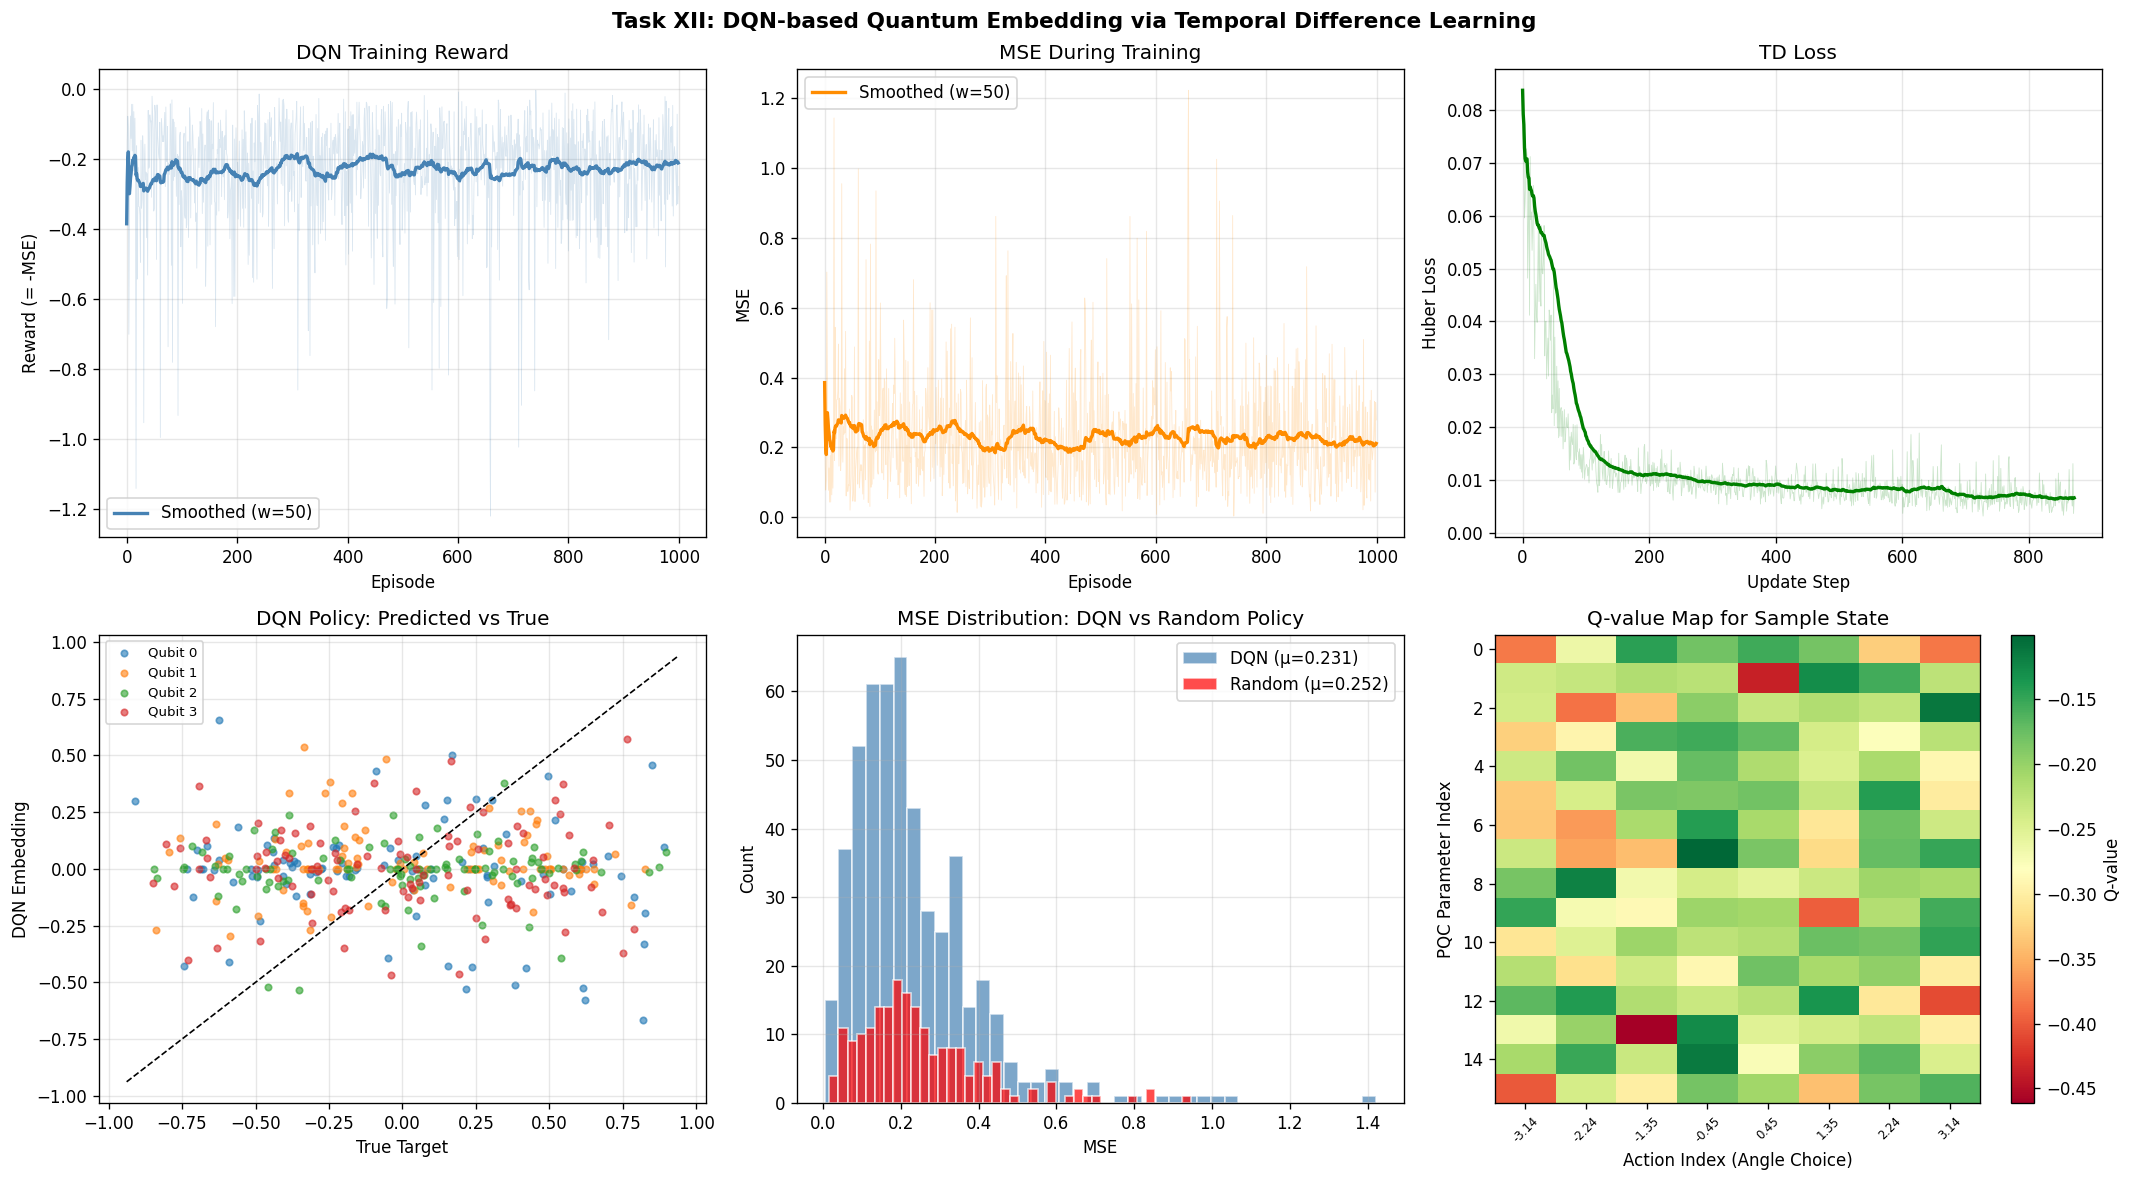

In [10]:
#Visualize training progress & results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0, 0]
window = 50
smoothed = [np.mean(episode_rewards[max(0,i-window):i+1]) for i in range(len(episode_rewards))]
ax.plot(episode_rewards, alpha=0.2, color='steelblue', lw=0.5)
ax.plot(smoothed, color='steelblue', lw=2, label=f'Smoothed (w={window})')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward (= -MSE)')
ax.set_title('DQN Training Reward')
ax.legend()
ax.grid(alpha=0.3)

#(2) MSE over episodes
ax = axes[0, 1]
smoothed_mse = [np.mean(episode_mses[max(0,i-window):i+1]) for i in range(len(episode_mses))]
ax.plot(episode_mses, alpha=0.2, color='darkorange', lw=0.5)
ax.plot(smoothed_mse, color='darkorange', lw=2, label=f'Smoothed (w={window})')
ax.set_xlabel('Episode')
ax.set_ylabel('MSE')
ax.set_title('MSE During Training')
ax.legend()
ax.grid(alpha=0.3)

# (3) TD Loss
ax = axes[0, 2]
if td_losses:
    smoothed_td = [np.mean(td_losses[max(0,i-50):i+1]) for i in range(len(td_losses))]
    ax.plot(td_losses, alpha=0.2, color='green', lw=0.5)
    ax.plot(smoothed_td, color='green', lw=2)
ax.set_xlabel('Update Step')
ax.set_ylabel('Huber Loss')
ax.set_title('TD Loss')
ax.grid(alpha=0.3)

# (4) Predicted vs True
ax = axes[1, 0]
for dim in range(N_QUBITS):
    ax.scatter(targets_out[:100, dim], embeddings_out[:100, dim],
               s=15, alpha=0.6, label=f'Qubit {dim}')
lo, hi = targets_out.min(), targets_out.max()
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
ax.set_xlabel('True Target')
ax.set_ylabel('DQN Embedding')
ax.set_title('DQN Policy: Predicted vs True')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# (5) MSE distribution comparison
ax = axes[1, 1]
ax.hist(greedy_mses, bins=40, alpha=0.7, color='steelblue', label=f'DQN (μ={np.mean(greedy_mses):.3f})', edgecolor='white')
ax.hist(random_mses, bins=40, alpha=0.7, color='red', label=f'Random (μ={np.mean(random_mses):.3f})', edgecolor='white')
ax.set_xlabel('MSE')
ax.set_ylabel('Count')
ax.set_title('MSE Distribution: DQN vs Random Policy')
ax.legend()
ax.grid(alpha=0.3)

# (6) Q-value heatmap for a sample state
ax = axes[1, 2]
sample_state = data[0]
with torch.no_grad():
    q_vals = q_net(sample_state.unsqueeze(0))[0].numpy()
im = ax.imshow(q_vals, aspect='auto', cmap='RdYlGn', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Q-value')
ax.set_xlabel('Action Index (Angle Choice)')
ax.set_ylabel('PQC Parameter Index')
ax.set_title(f'Q-value Map for Sample State')
ax.set_xticks(range(K_ACTIONS))
ax.set_xticklabels([f'{a:.2f}' for a in ACTION_ANGLES.numpy()], rotation=45, fontsize=7)

plt.suptitle('Task XII: DQN-based Quantum Embedding via Temporal Difference Learning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task_xii_results.png', bbox_inches='tight')
plt.show()